In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

xl = pd.ExcelFile('/Users/headofthetable/inventory-optimisation/data/raw/Apparel_Store_Inventory_JIT_Dataset.xlsx')
sales = pd.read_excel(xl, 'Daily_Sales_Transactions', header=3)
products = pd.read_excel(xl, 'Product_Master', header=3)

sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)

print("Loaded:", sales.shape)

Task was destroyed but it is pending!
task: <Task pending name='Task-302' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/inventory-project/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-303' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/inventory-project/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/inventory-project/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
<frozen abc>:123: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
Task was destroyed but it is pending!
task: <Task pending name='Task-303' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/inventory-project/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-320' coro=<_async_in_context.<locals

Loaded: (45423, 11)


In [7]:
# Prophet requires columns named 'ds' (date) and 'y' (value)
sales_full = sales.merge(
    products[['SKU', 'Sub-Category', 'Brand Line']], 
    on='SKU', how='left'
)

# Get daily CasualCo T-shirt sales
casualco = (
    sales_full[
        (sales_full['Sub-Category'] == 'T-Shirts') & 
        (sales_full['Brand Line'] == 'CasualCo')
    ]
    .groupby('Date')['Units Sold']
    .sum()
    .reset_index()
)

casualco.columns = ['ds', 'y']
casualco = casualco.sort_values('ds').reset_index(drop=True)

print("CasualCo daily data shape:", casualco.shape)
print(casualco.head())
print()
print("Date range:", casualco['ds'].min(), "to", casualco['ds'].max())
print("Average daily sales:", casualco['y'].mean().round(2))

CasualCo daily data shape: (181, 2)
          ds   y
0 2026-01-01  22
1 2026-01-02  24
2 2026-01-03  33
3 2026-01-04  28
4 2026-01-05  27

Date range: 2026-01-01 00:00:00 to 2026-06-30 00:00:00
Average daily sales: 18.93


12:12:50 - cmdstanpy - INFO - Chain [1] start processing
12:12:50 - cmdstanpy - INFO - Chain [1] done processing


Training days: 150
Test days: 31
Test period: 2026-05-31 00:00:00 to 2026-06-30 00:00:00


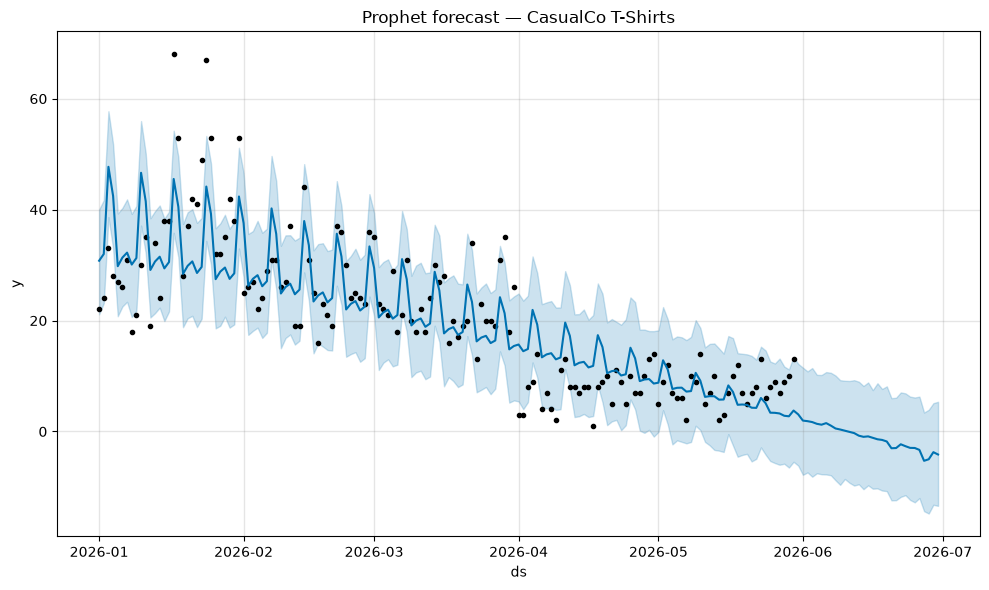

Forecast for last 31 days (sample):
            ds      yhat  yhat_lower  yhat_upper
150 2026-05-31  3.082276   -6.152223   12.196446
151 2026-06-01  1.966598   -7.811571   11.505757
152 2026-06-02  1.861343   -7.383502   10.841680
153 2026-06-03  1.698822   -8.152938   11.439509
154 2026-06-04  1.383269   -7.539873   10.213078


In [8]:
# Split — train on first 150 days, test on last 31 days
train = casualco[:150]
test = casualco[150:]

print("Training days:", len(train))
print("Test days:", len(test))
print("Test period:", test['ds'].min(), "to", test['ds'].max())

# Train Prophet model
model = Prophet(
    yearly_seasonality=False,  # only 6 months of data
    weekly_seasonality=True,   # weekly patterns exist
    daily_seasonality=False,   # not needed for retail
    seasonality_mode='multiplicative'  # spikes scale with level
)

model.fit(train)

# Forecast for test period
future = model.make_future_dataframe(periods=31)
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.title('Prophet forecast — CasualCo T-Shirts')
plt.tight_layout()
plt.show()

print("Forecast for last 31 days (sample):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(31).head(5))

In [9]:

from sklearn.metrics import mean_absolute_error

# Compare Prophet predictions vs actual for test period
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds','yhat']]
test_forecast = test_forecast.merge(test, on='ds')

# Clip negative predictions to 0 — can't sell negative units
test_forecast['yhat'] = test_forecast['yhat'].clip(lower=0)

mae_prophet = mean_absolute_error(test_forecast['y'], test_forecast['yhat'])

print(f"Prophet MAE: {mae_prophet:.1f} units/day")
print(f"That's {mae_prophet * 30:.0f} units error per month")
print()
print("Actual avg daily sales in test:", test['y'].mean().round(1))
print("Prophet avg daily prediction:", test_forecast['yhat'].mean().round(1))



# Compare Prophet predictions vs actual for test period
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds','yhat']]
test_forecast = test_forecast.merge(test, on='ds')

# Clip negative predictions to 0 — can't sell negative units
test_forecast['yhat'] = test_forecast['yhat'].clip(lower=0)

mae_prophet = mean_absolute_error(test_forecast['y'], test_forecast['yhat'])

print(f"Prophet MAE: {mae_prophet:.1f} units/day")
print(f"That's {mae_prophet * 30:.0f} units error per month")
print()
print("Actual avg daily sales in test:", test['y'].mean().round(1))
print("Prophet avg daily prediction:", test_forecast['yhat'].mean().round(1))

Prophet MAE: 11.1 units/day
That's 334 units error per month

Actual avg daily sales in test: 11.6
Prophet avg daily prediction: 0.5
Prophet MAE: 11.1 units/day
That's 334 units error per month

Actual avg daily sales in test: 11.6
Prophet avg daily prediction: 0.5


## Prophet Results — CasualCo T-Shirts
- Prophet MAE: 11.1 units/day (334 units/month)
- Predicted 0.5 units/day vs actual 11.6 units/day
- Prophet learned EOSS spike as a downward trend
- Extrapolated to near-zero demand by June
- Root cause: 6 months data insufficient, EOSS spike 
  at start creates false trend signal
- Both regression and Prophet fail on CasualCo
- Decision: use simple average velocity for CasualCo 
  until more historical data is available
- This is the honest finding — document it

In [10]:
stable_period = casualco[casualco['ds'] >= '2026-04-01']
simple_avg = stable_period['y'].mean()
simple_mae = mean_absolute_error(test['y'], 
             [simple_avg] * len(test))

print(f"Simple average forecast: {simple_avg:.1f} units/day")
print(f"Simple average MAE: {simple_mae:.1f} units/day")
print(f"That's {simple_mae * 30:.0f} units error per month")
print()
print("=== Model Comparison for CasualCo ===")
print(f"Prophet MAE:        {mae_prophet:.1f} units/day")
print(f"Simple average MAE: {simple_mae:.1f} units/day")
winner = "Simple Average" if simple_mae < mae_prophet else "Prophet"
print(f"Winner: {winner}")

Simple average forecast: 9.2 units/day
Simple average MAE: 3.9 units/day
That's 116 units error per month

=== Model Comparison for CasualCo ===
Prophet MAE:        11.1 units/day
Simple average MAE: 3.9 units/day
Winner: Simple Average


## Simple Average vs Prophet — CasualCo
- Simple average MAE: 3.9 units/day (116/month) 
- Prophet MAE: 11.1 units/day (334/month)
- Winner: Simple Average by 3x
- Key insight: sometimes the simplest model wins
- Reason: Prophet confused by EOSS spike, simple 
  average uses only stable recent period
- Decision: use Apr-Jun average (9.2 units/day) 
  as CasualCo forecast until more data available